In [1]:
import pandas as pd
import numpy as np


In [2]:
imoveis_clean = pd.read_csv("csv files/imoveisFinal.csv")


<h2 style="text-align: center;">Preparação dos Dados</h2>
<p style="text-align: center;">Aqui nessa seção os dados serão preparados para as análises que serão realizadas.</p>


<p style="text-align: center;">Abaixo são realizadas as conversões dos tipos da tabela e remoção de caracteres como "+", "m²", ".". É convertido De Object para String, então são removidos os caracteres de cada coluna e então elas são convertidas para números inteiros. Vale ressaltar que não foi necessário mexer com valores nulos, pois durante a extração de dados eles foram ignorados</p>


In [4]:
imoveis_clean["Numero de quartos"] = imoveis_clean["Numero de quartos"].astype(str).str.replace("+", "").astype(int)
imoveis_clean["Metros quadrados"] = imoveis_clean["Metros quadrados"].astype(str).str.replace("m²", "").astype(int)
imoveis_clean["Vagas de Garagem"] = imoveis_clean["Vagas de Garagem"].astype(str).str.replace("+", "").astype(int)
imoveis_clean["Numero de Banheiros"] = imoveis_clean["Numero de Banheiros"].astype(str).str.replace("+", "").astype(int)
imoveis_clean["Preço"] = imoveis_clean["Preço"].astype(str).str.replace("R$", "").str.replace(".", "").astype(int)


<p style="text-align: center;">Aqui é realizada a manipulação de um novo dataframe para analisar os preços do metro quadrado de cada bairro, além da quantidade de vezes que um bairro aparece no dataset. O novo dataframe terá colunas para o bairro do imóvel, o número de imóveis desse bairro, a soma de todos os preços, a soma de toda a área e depois será adicionada a coluna que mostra o preço do metro quadrado por bairro. Também é feito a remoção de qualquer imóvel que não é de Londrina, já que durante a coleta dos dados alguns dados de cidades da região de Londrina apareceram no dataset. 
</p>


In [5]:
count = 0
bairrosList = []
countList = []
precosList = []
m2List = []

bairrosDict = {}
for bairro, preco, m2 in zip(imoveis_clean["Bairro"],imoveis_clean["Preço"], imoveis_clean["Metros quadrados"]):
    
    if len(bairro.split("Londrina, ")) > 1:
        bairrosLondrina = bairro.split("Londrina, ")[-1]
        if bairrosLondrina not in bairrosDict:
            bairrosDict[bairrosLondrina] = 1
            
            bairrosList.append(bairrosLondrina)
            countList.append(bairrosDict[bairrosLondrina])
            precosList.append(preco)
            m2List.append(m2)
        else:
            bairrosDict[bairrosLondrina] = bairrosDict[bairrosLondrina] + 1
            index = bairrosList.index(bairrosLondrina)
            countList[index] = bairrosDict[bairrosLondrina]
            precosList[index] += preco
            m2List[index] += m2

bairrosDFDict = {"Bairro": bairrosList,
                 "Número de imóveis": countList,
                 "Preço total": precosList,
                 "M2 Total": m2List
}

bairrosDF = pd.DataFrame(bairrosDFDict) 
bairrosDF

,Bairro,Número de imóveis,Preço total,M2 Total
0,Vale dos Tucanos,159,59053680,11940
1,Guanabara Parque Boulevard,91,84769989,8911
2,Jardim Santa Cruz,69,11540198,4326
3,Jardim Palmas,4,985000,417
4,Nossa Senhora de Lourdes,77,24551710,6398
...,...,...,...,...
424,Recanto do Pitanguá,2,6599000,924
425,Recanto Nobre,6,71410000,5099
426,Maravilha,1,1700000,220
427,Vale do Reno,1,1890000,369


In [6]:
from sklearn.utils import shuffle


imoveis_filtrado = imoveis_clean[imoveis_clean["Bairro"].str.contains("Londrina, ")].copy()
imoveis_filtrado["Bairro"] = imoveis_filtrado["Bairro"].str.replace("Londrina, ", "")

final_imoveis_filtrado = shuffle(imoveis_filtrado)

final_imoveis_filtrado.to_csv("csv files/imoveisTraining.csv", index = False)

In [7]:
bairrosDF["Preço por M²"] = (bairrosDF["Preço total"]/bairrosDF["M2 Total"]).round(2)


<h2 style="text-align: center;">Análise Descritiva
</h2>


In [46]:
import matplotlib.pyplot as plt

precosM2Bairros = bairrosDF["Preço por M²"]
precosImoveis = final_imoveis_filtrado["Preço"]/100000
mediaPrecosM2 = bairrosDF["Preço por M²"].mean()

print(mediaPrecosM2)


4054.4194172494176


4054.4194172494176
3644.29


{'whiskers': [<matplotlib.lines.Line2D at 0x256da91c460>,
 'caps': [<matplotlib.lines.Line2D at 0x256da91c9a0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x256da91c100>],
 'medians': [<matplotlib.lines.Line2D at 0x256da91cee0>],
 'fliers': [<matplotlib.lines.Line2D at 0x256da92a1c0>],
 'means': []}

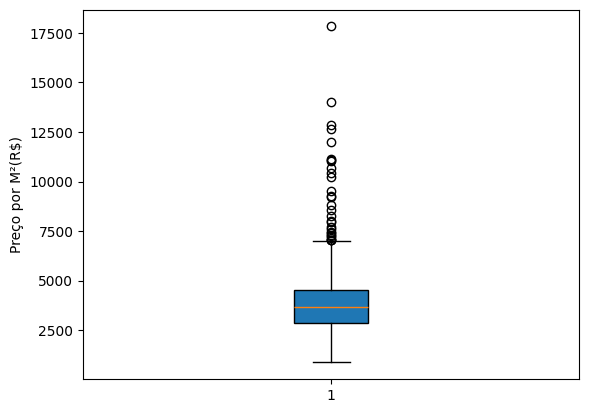

In [56]:
print(precosM2Bairros.mean())
print(precosM2Bairros.median())

plt.ylabel('Preço por M²(R$)')


plt.boxplot(precosM2Bairros, patch_artist=True)

939097.8596207964
520000.0


{'whiskers': [<matplotlib.lines.Line2D at 0x256da86e730>,
 'caps': [<matplotlib.lines.Line2D at 0x256da86ec70>,
 'boxes': [<matplotlib.patches.PathPatch at 0x256da86e340>],
 'medians': [<matplotlib.lines.Line2D at 0x256da87d1f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x256da87d490>],
 'means': []}

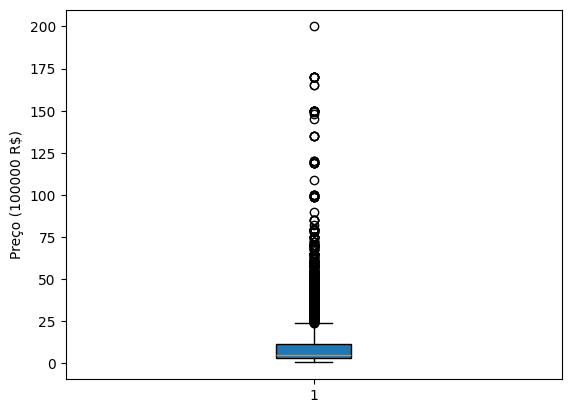

In [54]:

print(precosImoveis.mean()*100000)
print(precosImoveis.median()*100000)

plt.ylabel('Preço (100000 R$)')
plt.boxplot(precosImoveis, patch_artist=True)

<h2 style="text-align: center;">Views dos dados 
</h2>


In [10]:
bairrosSortedNumeroImoveis = bairrosDF.sort_values(by=['Número de imóveis'], ascending = False)
bairrosSortedPrecoPorM2Asc = bairrosDF.sort_values(by=['Preço por M²'], ascending = False)
bairrosSortedPrecoPorM2Desc = bairrosDF.sort_values(by=['Preço por M²'])

bairrosSortedPrecoPorM2Asc.head(11)

,Bairro,Número de imóveis,Preço total,M2 Total,Preço por M²
422,Condomínio Royal Golf Residence,12,146590000,8223,17826.83
425,Recanto Nobre,6,71410000,5099,14004.71
106,Vivendas do Arvoredo,240,905770000,70572,12834.69
241,Guanabara,71,286268980,22651,12638.25
320,Bela Suiça,267,919409868,76718,11984.28
351,Santa Rosa,471,838318360,75188,11149.63
43,Jardim São Jorge,82,268415388,24197,11092.92
406,Vila Zelina,1,1149900,104,11056.73
390,Nikko,24,55218000,5175,10670.14
34,Gleba Fazenda Palhano,2962,3893637715,372901,10441.48


In [11]:
bairrosSortedPrecoPorM2Desc.head(11)

,Bairro,Número de imóveis,Preço total,M2 Total,Preço por M²
255,Jardim Mairá,2,430000,496,866.94
308,Eliza,1,320000,280,1142.86
261,Franciscato,1,200000,160,1250.00
226,Giovani Lunardelli,14,5973740,4179,1429.47
205,Conjunto Habitacional Mister Thomas,6,1448000,937,1545.36
263,Carlota,3,657000,419,1568.02
116,Jardim União da Vitória II,3,445000,281,1583.63
372,Arpoador,2,1000000,624,1602.56
251,Fraternidade,4,1130000,693,1630.59
193,Jardim Santa Maria,1,240000,146,1643.84



<h2 style="text-align: center;">Obtenção dos dados para o mapa</h2>


In [52]:
!k2g map_data/bairrosLondrina.kml map_data

In [53]:
import json
import folium

bairrosList = []

with open("map_data\style.json", 'r') as file: 
    bairrosJSON = json.load(file)
#[-23.32243, -51.15817] coordenadas do centro de londrina

#print(bairrosJSON)

for features in bairrosJSON["features"]:
    bairrosList.append(features["properties"]["BAIRRO"])
        
#print(bairrosJSON.items()) 
print(bairrosList)
len(bairrosList)

['Alpes', 'Coliseu', 'Shangri-lá', 'Vila Nova', 'Vila Recreio', 'Vila Casoni', 'Centro', 'Vila Brasil', 'Ipiranga', 'Nova Esperança', 'Petrópolis', 'Higienópolis', 'Quebec', 'Presidente', 'Parque das Indústrias Leves', 'Pioneiros', 'Interlagos', 'Fraternidade', 'Ideal', 'Cilo 2', 'Bandeirantes', 'Tókio', 'Abussafe', 'Antares', 'Vila Siam', 'Ernani', 'Califórnia', 'Piza', 'Inglaterra', 'Tucanos', 'Bela Suiça', 'Guanabara', 'Leonor', 'Vista Bela', 'Cilo 3', 'Ouro Verde', 'Heimtal', 'Cinco Conjuntos', 'Cidade Industrial 1', 'Lindóia', 'Parigot', 'Primavera', 'Palhano 1', 'Palhano 2', 'Sabará', 'Cafezal', 'Carnascialli', 'Milton Gavetti', 'Novo Amparo', 'Alto Primavera', 'Vivendas do Arvoredo', 'São Miguel', 'Jamile Dequech', 'União da Vitória', 'Industrial 4', 'São Lourenço', 'Columbia', 'Olímpico', 'Maria Celina', 'Royal', 'Paris', 'Terra Nova', 'Vivi Xavier', 'Aeroporto', 'Perobinha', 'São Jorge']


66

In [54]:
b_dict = {"Bairro": bairrosList}

bairrosMapaCheckDF = pd.DataFrame(b_dict)

#matchingBairros = bairrosDF.query("Bairro in @bairrosList")
#missingBairros = bairrosDF.query("Bairro not in @bairrosList")

listaBairros = bairrosDF['Bairro'].tolist()


matchingBairros = bairrosMapaCheckDF.query("Bairro in @listaBairros")
missingBairros = bairrosMapaCheckDF.query("Bairro not in @listaBairros")

#for bairros in bairrosList:
 #   if len(bairrosDF.query("Bairro == @bairros"))

bairrosUnidosDF = pd.concat([matchingBairros, missingBairros]) 

missingBairros
bairrosDF
bairrosUnidosDF

,Bairro
0,Alpes
1,Coliseu
2,Shangri-lá
3,Vila Nova
5,Vila Casoni
...,...
59,Royal
60,Paris
61,Terra Nova
62,Vivi Xavier


In [55]:


def matchBairros(bairros):
    match = bairrosDF[bairrosDF["Bairro"].str.contains(bairros, case=False, na=False)]
    if len(match) > 1:
        
        return ",".join(match["Bairro"])
    elif len(match) == 1:
        return match["Bairro"].values[0]
    else:
        return "None"

def matchAjuste(bairros):
    
    match = bairrosDF[bairrosDF["Bairro"].str.contains(bairros, case=False, na=False)]
    if len(match) > 1:
        m2Total = match["M2 Total"].sum()
        precoTotal = match["Preço total"].sum()
        return (precoTotal/m2Total).round(2)
    
    elif len(match) == 1:
        return match["Preço por M²"].values[0].round(2)
    else:
        return 0


def getM2Missing(bairros):

    match = bairrosDF[bairrosDF["Bairro"] == bairros]
    return match["Preço por M²"].values[0].round(2)



In [56]:
bairrosMapaDF = pd.DataFrame()
missingBairrosCopy = missingBairros.copy()
matchingBairrosCopy = matchingBairros.copy()  

missingBairrosCopy["Bairros Match"] = missingBairrosCopy["Bairro"].apply(matchBairros)
missingBairrosCopy["Preço m²"] = missingBairrosCopy["Bairro"].apply(matchAjuste)

matchingBairrosCopy["Bairros Match"] = "None"
matchingBairrosCopy["Preço m²"] = matchingBairrosCopy["Bairro"].apply(getM2Missing)

bairrosComplete = pd.concat([matchingBairrosCopy, missingBairrosCopy])

In [57]:
bairrosCompleto = bairrosComplete.drop(["Bairros Match"], axis = 1)
indexNone = bairrosCompleto[bairrosCompleto["Preço m²"] == "None"].index.tolist()


bairroImoveisList = ["Gleba Fazenda Palhano", "Gleba Fazenda Palhano", "Recreio", "Parque das Indústrias,Indústrias Leves", "Jardim Colúmbia D,Colúmbia"]
bairroMapaList = ["Palhano 1", "Palhano 2", "Vila Recreio","Parque das Indústrias Leves", "Columbia" ]

nomesPossuem = {"Bairro Imoveis": bairroImoveisList, 
                "Bairro Mapa":  bairroMapaList
               }

mapsCompDF = pd.DataFrame(nomesPossuem)



def matchFinal(bairros):
    newBairros = bairros.replace(",", "|")

    match = bairrosDF[bairrosDF["Bairro"].str.contains(newBairros, case=False, na=False, regex=True)]
    
    if len(match) > 1:
        m2Total = match["M2 Total"].sum()
        precoTotal = match["Preço total"].sum()
        return (precoTotal/m2Total).round(2)
    elif len(match) == 1:
        return match["Preço por M²"].values[0]
    else:
        return 0


mapsCompDF["Preço m²"] = mapsCompDF["Bairro Imoveis"].apply(matchFinal)

mapsCompDFMerging = mapsCompDF.drop(["Bairro Imoveis"], axis = 1)
mapsCompDFMerging.rename(columns={"Bairro Mapa": "Bairro"}, inplace=True)

mapsCompDFMerging

,Bairro,Preço m²
0,Palhano 1,10441.48
1,Palhano 2,10441.48
2,Vila Recreio,2554.87
3,Parque das Indústrias Leves,3827.94
4,Columbia,3971.44


In [58]:
import numpy as np
import pandas as pd

# Merge apenas pelo nome do bairro
merged = pd.merge(
    bairrosCompleto, 
    mapsCompDFMerging[["Bairro", "Preço m²"]], 
    on="Bairro", 
    how="left", 
    suffixes=("", "_new")
)

# Substitui onde o valor for 0
merged["Preço m²"] = np.where(
    merged["Preço m²"] == 0,
    merged["Preço m²_new"],
    merged["Preço m²"]
)

# Remove coluna auxiliar
merged.drop(columns=["Preço m²_new"], inplace=True)
merged.head(50)

,Bairro,Preço m²
0,Alpes,3193.52
1,Coliseu,3575.36
2,Shangri-lá,3709.69
3,Vila Nova,3993.25
4,Vila Casoni,2884.95
5,Centro,5051.11
6,Vila Brasil,5389.57
7,Petrópolis,6122.93
8,Quebec,4100.01
9,Interlagos,2809.31


In [59]:
merged.to_csv("csv files/dadosMapa.csv", index = False)